In [3]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Step 1: Create the database and insert sample data
conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

In [4]:
# Create the sales table
cursor.execute("""
CREATE TABLE IF NOT EXISTS sales (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    product TEXT NOT NULL,
    quantity INTEGER NOT NULL,
    price REAL NOT NULL
)
""")

In [5]:
# Insert sample data
sample_data = [
    ("Apple", 10, 0.5),
    ("Banana", 20, 0.3),
    ("Orange", 15, 0.6),
    ("Apple", 5, 0.5),
    ("Banana", 10, 0.3),
    ("Orange", 10, 0.6)
]
cursor.execute("DELETE FROM sales")  # Clear old data for repeatable runs
cursor.executemany("INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)", sample_data)
conn.commit()

In [6]:
# Step 2: Run SQL query to summarize sales
query = """
SELECT 
    product, 
    SUM(quantity) AS total_qty, 
    SUM(quantity * price) AS revenue 
FROM sales 
GROUP BY product
"""
df = pd.read_sql_query(query, conn)

In [7]:
# Step 3: Print results
print("Sales Summary:")
print(df)

Sales Summary:
  product  total_qty  revenue
0   Apple         15      7.5
1  Banana         30      9.0
2  Orange         25     15.0


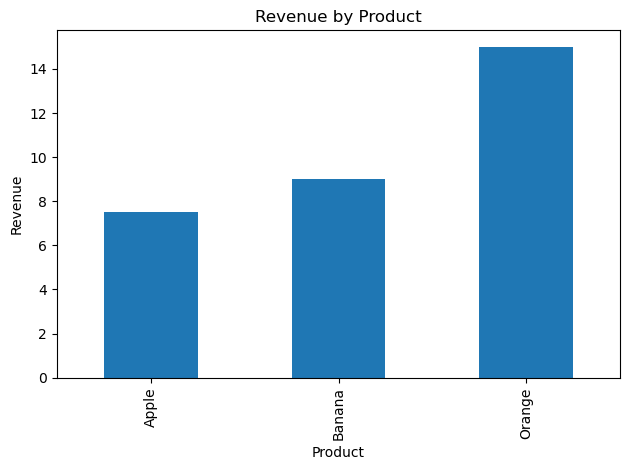

In [8]:
# Step 4: Plot revenue by product
df.plot(kind='bar', x='product', y='revenue', legend=False)
plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig("sales_chart.png")
plt.show()

In [9]:
# Step 5: Clean up
conn.close()